<a href="https://colab.research.google.com/github/PratyushJha254/BTech-Project/blob/main/XYModel_MetropolisAlgorithm_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from numba import jit

@jit(nopython=True)
def calculate_delta_E(grid, ix, iy, d_theta, J):
    """
    Compute the energy difference for rotating spin at (ix, iy) by d_theta.
    Periodic boundary conditions are assumed.
    """
    L = grid.shape[0]
    old_theta = grid[ix, iy]
    new_theta = old_theta + d_theta

    # wrap angles into [-pi, pi]
    if new_theta > np.pi:
        new_theta -= 2 * np.pi
    elif new_theta < -np.pi:
        new_theta += 2 * np.pi

    dE = 0.0
    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
        jx = (ix + dx) % L
        jy = (iy + dy) % L
        dE += -J * (np.cos(new_theta - grid[jx, jy]) - np.cos(old_theta - grid[jx, jy]))

    return dE


@jit(nopython=True)
def metropolis_update(grid, T, J, delta):
    """
    Perform one Metropolis sweep (L*L updates).
    """
    L = grid.shape[0]
    for _ in range(L * L):
        ix, iy = np.random.randint(0, L), np.random.randint(0, L)
        d_theta = np.random.uniform(-delta, delta)
        dE = calculate_delta_E(grid, ix, iy, d_theta, J)
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            grid[ix, iy] += d_theta
            # wrap back into [-pi, pi]
            if grid[ix, iy] > np.pi:
                grid[ix, iy] -= 2 * np.pi
            elif grid[ix, iy] < -np.pi:
                grid[ix, iy] += 2 * np.pi


def data_generation_internal(L, J, temperatures, ntherm=40000, nsamples=100, nskip=100, nbin=10, delta=0.5):
    """
    Generate XY model configurations using the Metropolis algorithm.

    Parameters
    ----------
    L : int
        Lattice size (LxL).
    J : float
        Coupling constant.
    temperatures : list or ndarray
        Temperatures to simulate.
    ntherm : int
        Number of thermalization sweeps.
    nsamples : int
        Number of samples to record per bin.
    nskip : int
        Number of sweeps to skip between samples.
    nbin : int
        Number of independent bins (random restarts).
    delta : float
        Proposal window size for angle updates (tune for ~50% acceptance).

    Returns
    -------
    C : ndarray, shape (len(temperatures)*nbin*nsamples, L, L)
        Configurations (angles in radians).
    Tvals : ndarray
        Corresponding temperatures for each configuration.
    """
    n = len(temperatures) * nbin * nsamples
    C = np.empty((n, L, L))
    Tvals = np.empty(n)

    c = 0
    for t in temperatures:
        for b in range(nbin):
            # start with random configuration
            grid = np.random.uniform(-np.pi, np.pi, size=(L, L))

            # thermalization
            for _ in range(ntherm):
                metropolis_update(grid, t, J, delta)

            # sampling
            for s in range(nsamples):
                for _ in range(nskip):
                    metropolis_update(grid, t, J, delta)
                C[c] = grid.copy()
                Tvals[c] = t
                c += 1

    return C, Tvals


In [ ]:
L = 32
J = 1.0
temps = np.arange(0.6, 1.2, 0.1)
C, Tvals = data_generation_internal(L, J, temps, ntherm=20000, nsamples=50, nskip=100, nbin=5)

print("Generated configs:", C.shape)   # (len(temps)*nbin*nsamples, L, L)


In [26]:
L = 64
J = 1.0
temps = np.arange(0.6, 1.4, 0.1)
C_64, Tvals_64 = data_generation_internal(L, J, temps, ntherm=20000, nsamples=50, nskip=100, nbin=5)

print("Generated configs:", C.shape)   # (len(temps)*nbin*nsamples, L, L)


Generated configs: (1500, 32, 32)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_data(data, temperature):
    # Define grid
    x = np.arange(0, 32, 1)
    y = np.arange(0, 32, 1)
    X, Y = np.meshgrid(x, y)

    # Calculate spin directions
    U = np.cos(data)
    V = np.sin(data)

    # Create plot
    fig, ax = plt.subplots(figsize=(30, 30))
    ax.quiver(X, Y, U, V, scale=3, units='xy', width=0.04, color='red', alpha=0.8)  # Adjust scale for larger arrows
    ax.set_aspect('equal', 'box')
    ax.set_title(f"Temperature: {temperature}")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.show()

# Example usage
# visualize_data(img[10], temperatures[10])


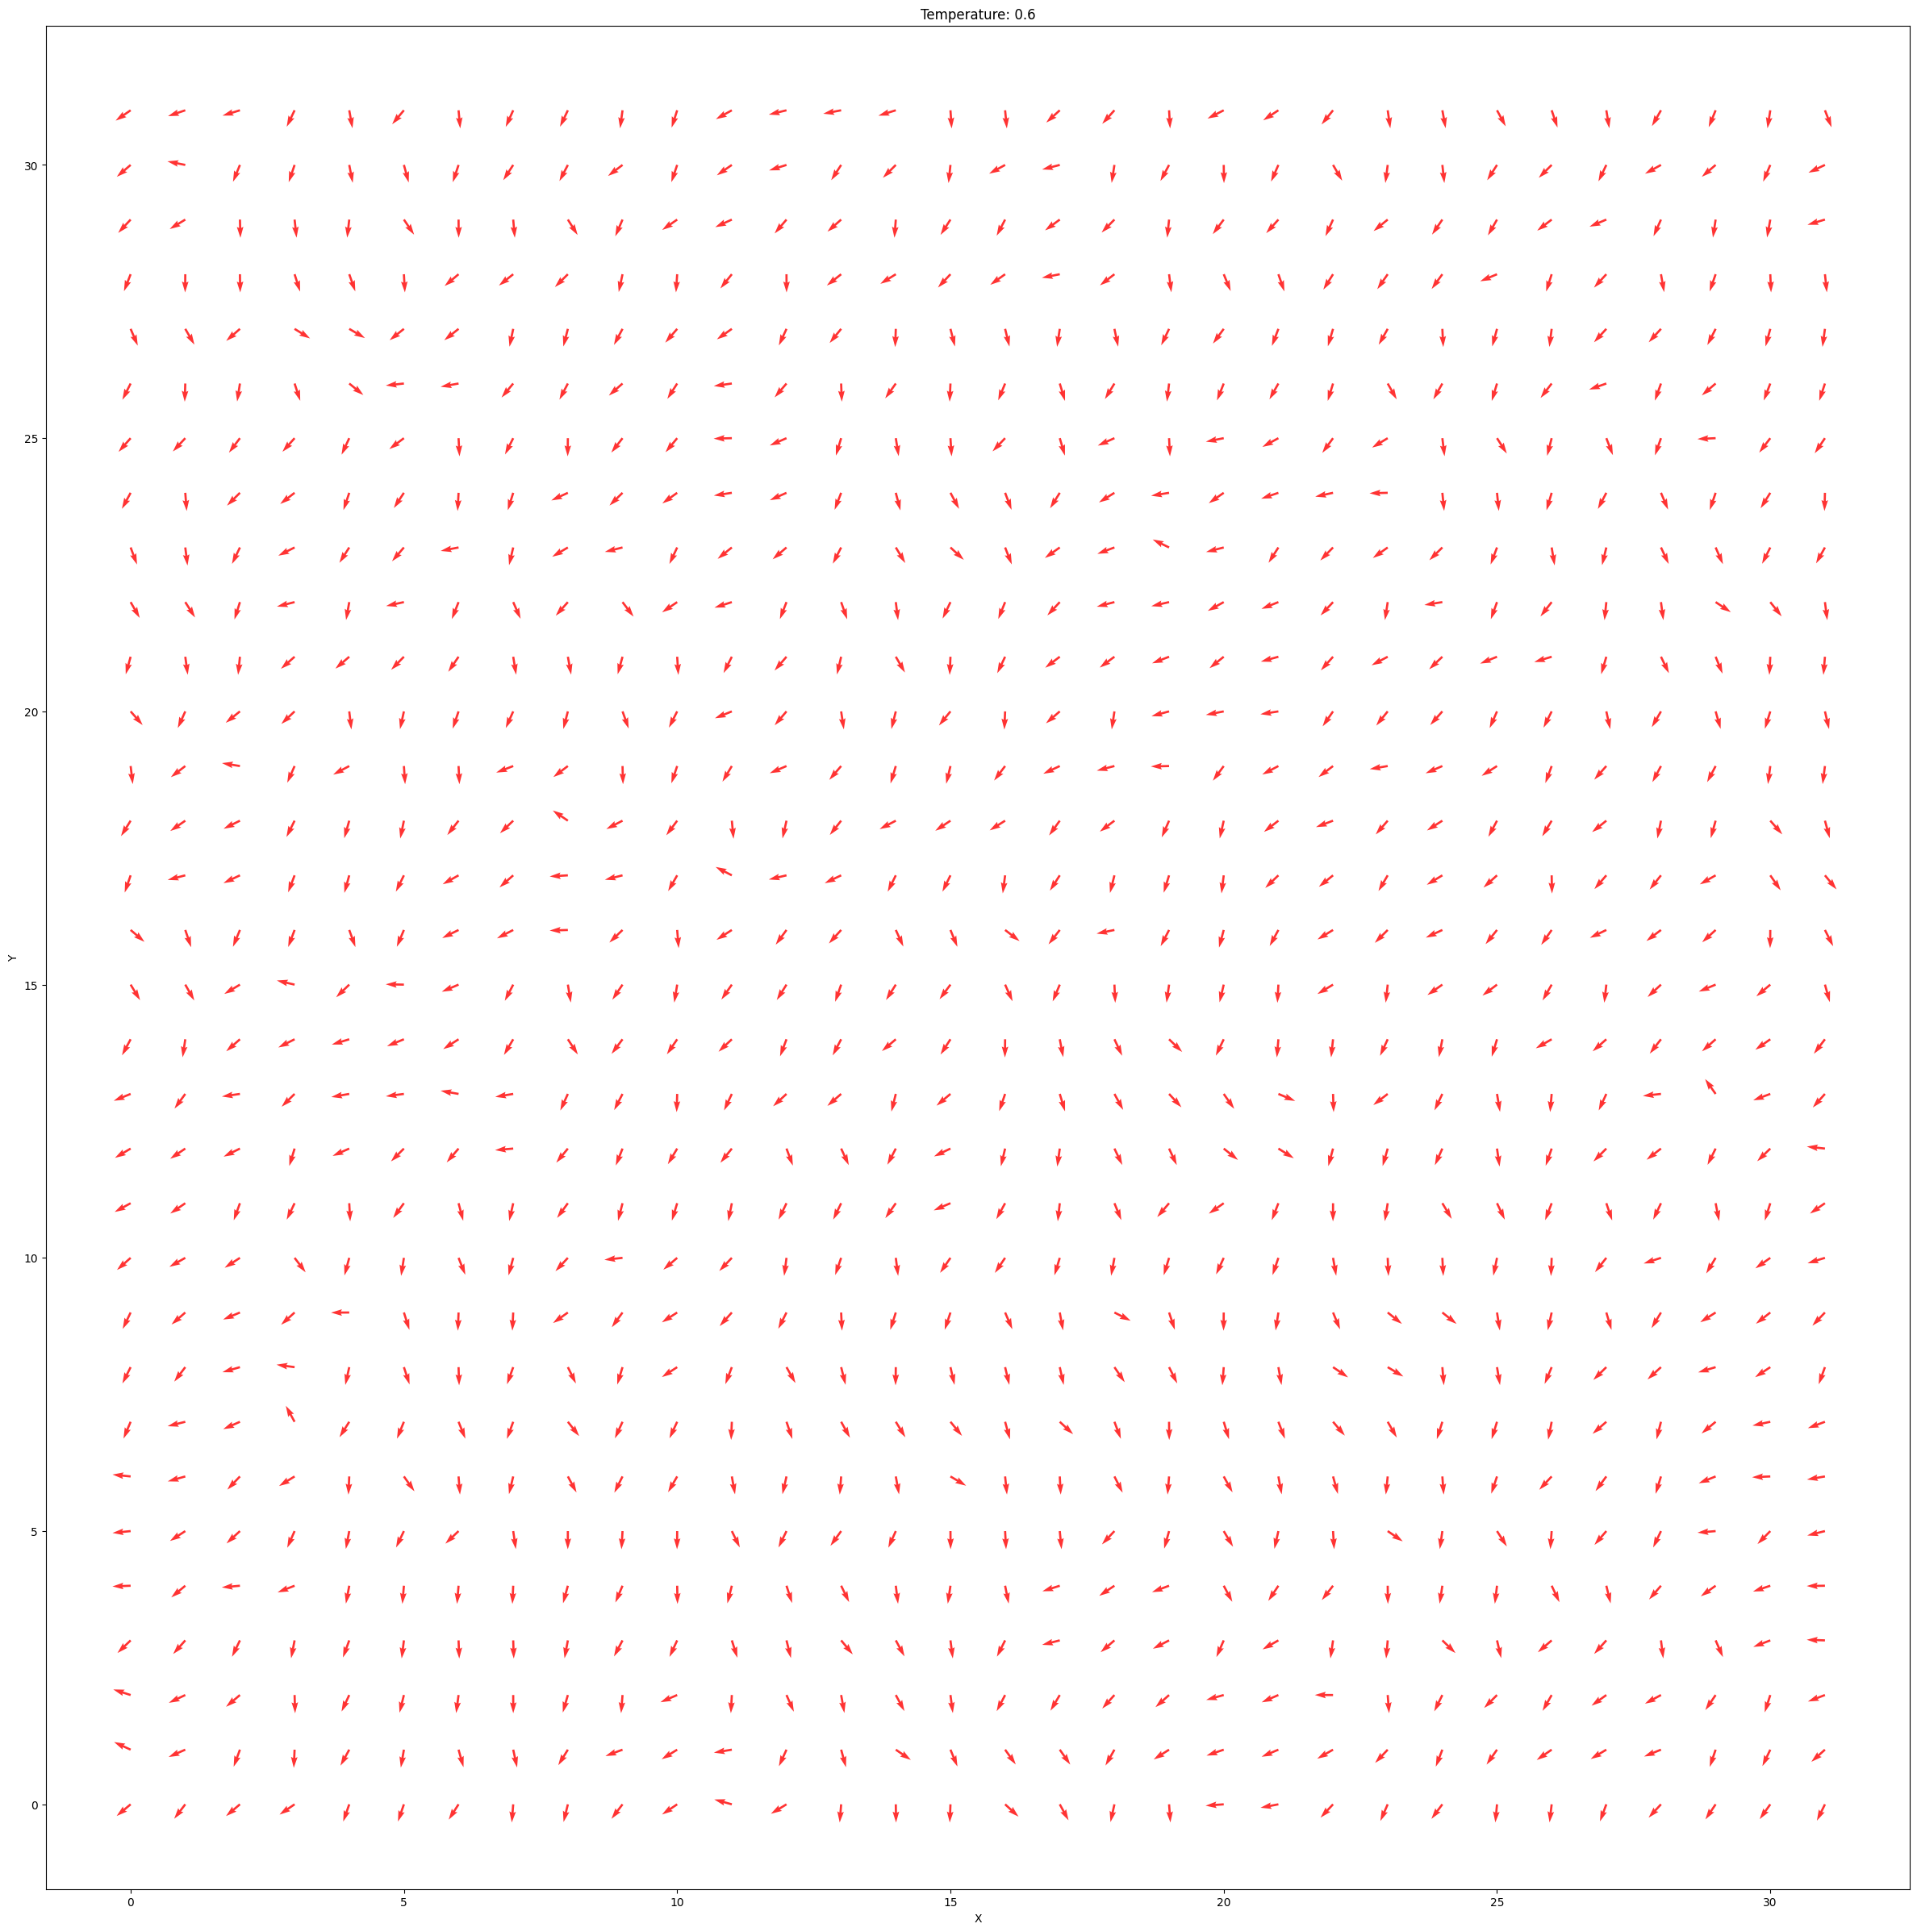

In [6]:
visualize_data(C[0], Tvals[0])

In [8]:
import numpy as np

def helicity_modulus(angles, beta):
    """
    Compute the helicity modulus (spin stiffness) for a 2D XY lattice.

    Parameters
    ----------
    angles : ndarray, shape (L, L)
        Spin angles in radians on each lattice site.
    beta : float
        Inverse temperature (1/T).

    Returns
    -------
    Ux, Uy : float
        Helicity modulus along x and y directions.
    """
    Lx, Ly = angles.shape
    N = Lx * Ly

    # Convert angles to spin vectors
    sx = np.cos(angles)
    sy = np.sin(angles)

    # Shifted neighbors (with periodic BCs)
    sx_x = np.roll(sx, -1, axis=0)
    sy_x = np.roll(sy, -1, axis=0)
    sx_y = np.roll(sx, -1, axis=1)
    sy_y = np.roll(sy, -1, axis=1)

    # Bond cos and sin along x
    cos_x = sx * sx_x + sy * sy_x
    sin_x = sx * sy_x - sy * sx_x

    # Bond cos and sin along y
    cos_y = sx * sx_y + sy * sy_y
    sin_y = sx * sy_y - sy * sx_y

    # Helicity modulus formula
    Ux = (np.sum(cos_x) / N) - (beta / N) * (np.sum(sin_x) ** 2)
    Uy = (np.sum(cos_y) / N) - (beta / N) * (np.sum(sin_y) ** 2)

    return Ux, Uy


# Example usage:
# Suppose angles is your 64x64 array, and T=0.5
# beta = 1.0 / T
# Ux, Uy = helicity_modulus(angles, beta)
# print("Helicity modulus:", Ux, Uy)


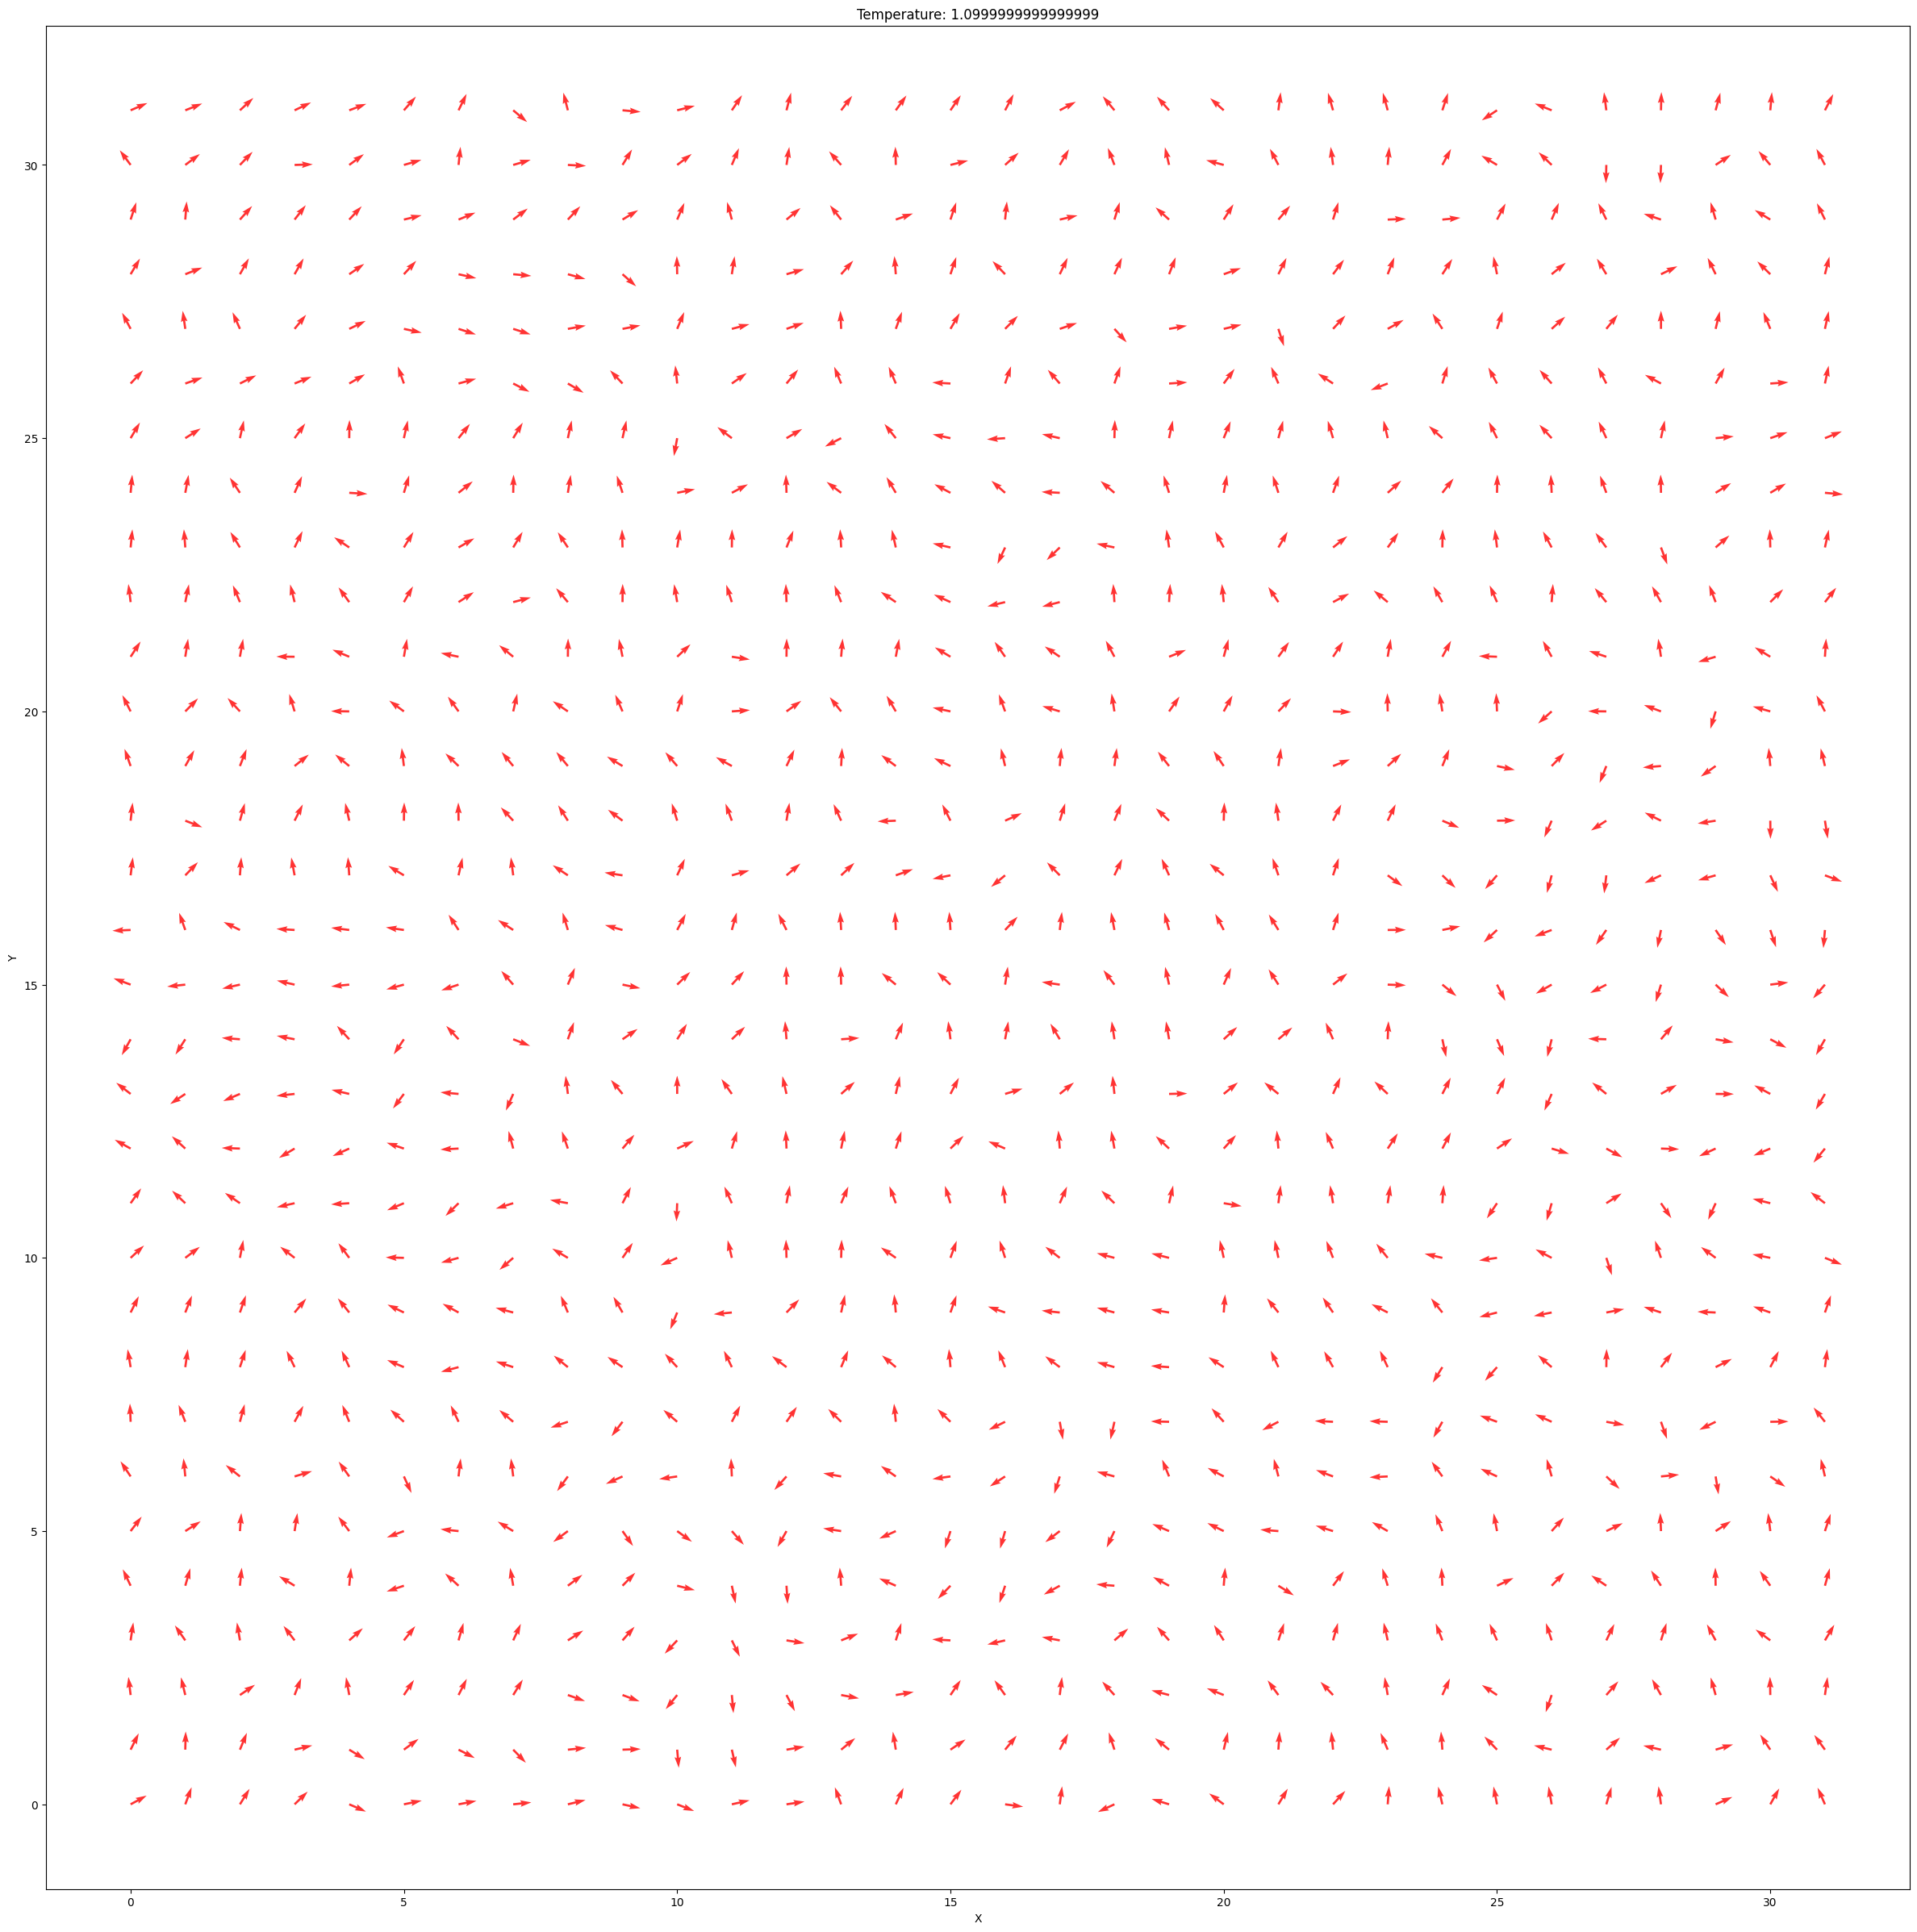

In [11]:
visualize_data(C[-12], Tvals[-12])

In [23]:
# Suppose spins is your 64x64x2 array, and T=0.5
idx = 700
print(Tvals[idx])
beta = 1.0 / Tvals[idx]
Ux, Uy = helicity_modulus(C[idx], beta)
print("Helicity modulus:", Ux, Uy)

0.7999999999999999
Helicity modulus: 0.6179669829706911 0.6403537079399697


In [24]:
import numpy as np
import matplotlib.pyplot as plt

def helicity_modulus_ensemble(configs, beta):
    """
    Ensemble helicity modulus for a set of configurations.

    configs: ndarray (M, L, L) of angles (radians)
    beta: float (1/T)

    returns: Ux, Uy, diagnostics
    """
    M, Lx, Ly = configs.shape
    N = Lx * Ly

    sx = np.cos(configs)      # shape (M, Lx, Ly)
    sy = np.sin(configs)

    # neighbors (axis 1 -> x, axis 2 -> y)
    sx_x = np.roll(sx, -1, axis=1)
    sy_x = np.roll(sy, -1, axis=1)
    sx_y = np.roll(sx, -1, axis=2)
    sy_y = np.roll(sy, -1, axis=2)

    # bond cos and sin per sample
    cos_x = sx * sx_x + sy * sy_x     # (M, Lx, Ly)
    sin_x = sy * sx_x - sx * sy_x     # sin(theta_i - theta_j) for x-bonds
    cos_y = sx * sx_y + sy * sy_y
    sin_y = sy * sx_y - sx * sy_y

    # first term: average over samples of (sum cos)/N
    first_x_per_sample = np.sum(cos_x, axis=(1,2)) / N   # (M,)
    first_y_per_sample = np.sum(cos_y, axis=(1,2)) / N

    first_x = np.mean(first_x_per_sample)
    first_y = np.mean(first_y_per_sample)

    # second term: beta/N * mean( (sum sin)^2 )
    sum_sin_x_per_sample = np.sum(sin_x, axis=(1,2))     # (M,)
    sum_sin_y_per_sample = np.sum(sin_y, axis=(1,2))

    second_x = (beta / N) * np.mean(sum_sin_x_per_sample**2)
    second_y = (beta / N) * np.mean(sum_sin_y_per_sample**2)

    Ux = first_x - second_x
    Uy = first_y - second_y

    diagnostics = {
        'first_x_mean': first_x,
        'first_y_mean': first_y,
        'second_x_mean': second_x,
        'second_y_mean': second_y,
        'first_x_std': np.std(first_x_per_sample, ddof=1) if M>1 else 0.0,
        'first_y_std': np.std(first_y_per_sample, ddof=1) if M>1 else 0.0,
        'sum_sin_x_std': np.std(sum_sin_x_per_sample, ddof=1) if M>1 else 0.0,
        'sum_sin_y_std': np.std(sum_sin_y_per_sample, ddof=1) if M>1 else 0.0,
        'M': M, 'N': N
    }

    return Ux, Uy, diagnostics


def helicity_modulus_bootstrap(configs, nboot, random_state=None):
    """
    Bootstrap helicity modulus on the given configs.
    Returns (Ux_mean, Ux_std), (Uy_mean, Uy_std).
    """
    rng = np.random.default_rng(random_state)
    M = configs.shape[0]
    Ux_boot = np.empty(nboot)
    Uy_boot = np.empty(nboot)
    for b in range(nboot):
        idx = rng.integers(0, M, size=M)
        sample = configs[idx]
        beta = 1.0 / 1.0  # dummy; will be set properly below in compute loop
        # We'll call helicity_modulus_ensemble with correct beta in compute function
        # This helper expects configs only; we'll avoid setting beta here and instead
        # use a closure in compute function (so we won't call this helper directly).
        # (Left here for API completeness; see compute function below.)
        raise RuntimeError("Call helicity_modulus_bootstrap through compute_helicity_vs_temp wrapper that sets beta.")
    # unreachable


def compute_helicity_vs_temp(C, Tvals, do_bootstrap=True, nboot=200, random_state=None):
    """
    Compute Ux(T), Uy(T) (and errors) from dataset C, Tvals.

    C: ndarray (n, L, L) -- configurations (angles)
    Tvals: ndarray (n,) -- temperatures corresponding to each config
    do_bootstrap: whether to compute bootstrap errors (if False, uses std/sqrt(M))
    nboot: number bootstrap resamples per temperature
    """
    # unique temps (sorted). Use np.unique then sort to be robust.
    unique_temps = np.unique(Tvals)
    unique_temps = np.sort(unique_temps)

    temps_list = []
    Ux_list = []
    Uy_list = []
    Ux_err = []
    Uy_err = []

    rng = np.random.default_rng(random_state)

    for t in unique_temps:
        mask = np.isclose(Tvals, t, atol=1e-8)
        configs = C[mask]
        M = configs.shape[0]
        if M == 0:
            continue

        beta = 1.0 / float(t)
        Ux, Uy, diag = helicity_modulus_ensemble(configs, beta)

        # estimate error bars
        if do_bootstrap and M > 1:
            Ux_boot = np.empty(nboot)
            Uy_boot = np.empty(nboot)
            for b in range(nboot):
                idx = rng.integers(0, M, size=M)
                sample = configs[idx]
                Ux_b, Uy_b, _ = helicity_modulus_ensemble(sample, beta)
                Ux_boot[b] = Ux_b
                Uy_boot[b] = Uy_b
            Ux_err_val = np.std(Ux_boot, ddof=1)
            Uy_err_val = np.std(Uy_boot, ddof=1)
        else:
            # simple standard-error estimate from per-sample contributions
            # approximate var(U) ~ var(first-term) + (beta/N)^2 var((sum sin)^2) ... rough.
            # Simpler: use std of per-sample first-term and of sum_sin to get rough errors:
            # (this is not rigorous but gives an idea if bootstrap is turned off)
            Ux_err_val = diag['first_x_std'] / np.sqrt(max(1, M))
            Uy_err_val = diag['first_y_std'] / np.sqrt(max(1, M))

        temps_list.append(t)
        Ux_list.append(Ux)
        Uy_list.append(Uy)
        Ux_err.append(Ux_err_val)
        Uy_err.append(Uy_err_val)

    # convert to arrays
    temps_arr = np.array(temps_list)
    Ux_arr = np.array(Ux_list)
    Uy_arr = np.array(Uy_list)
    Ux_err = np.array(Ux_err)
    Uy_err = np.array(Uy_err)

    return temps_arr, Ux_arr, Uy_arr, Ux_err, Uy_err


def plot_helicity_vs_temp(temps, Ux, Uy, Ux_err=None, Uy_err=None, title="Helicity modulus vs Temperature"):
    """
    Plot Ux and Uy vs T with error bars.
    """
    plt.figure(figsize=(7,5))
    # Ux
    if Ux_err is not None:
        plt.errorbar(temps, Ux, yerr=Ux_err, marker='o', linestyle='-', label=r'$Υ_x$')
    else:
        plt.plot(temps, Ux, marker='o', linestyle='-', label=r'$Υ_x$')
    # Uy
    if Uy_err is not None:
        plt.errorbar(temps, Uy, yerr=Uy_err, marker='s', linestyle='--', label=r'$Υ_y$')
    else:
        plt.plot(temps, Uy, marker='s', linestyle='--', label=r'$Υ_y$')

    plt.axhline(0.0, linestyle=':', linewidth=1)
    plt.xlabel("Temperature T")
    plt.ylabel("Helicity modulus $Υ$")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -------------------------
# Example usage (drop into your notebook/script)
# -------------------------
# Suppose you already generated:
#   C, Tvals = data_generation_internal(L, J, temperatures, ntherm=..., nsamples=..., nskip=..., nbin=..., delta=...)
#
# Then:
# temps, Ux, Uy, Ux_err, Uy_err = compute_helicity_vs_temp(C, Tvals, do_bootstrap=True, nboot=200)
# plot_helicity_vs_temp(temps, Ux, Uy, Ux_err=Ux_err, Uy_err=Uy_err)
#
# Notes:
# - If your dataset is large, set nboot smaller (50-200) to save time.
# - Ensure C contains independent samples per temperature (post-thermalization + thinning).
# - If you want only Ux, you can ignore Uy in plotting.


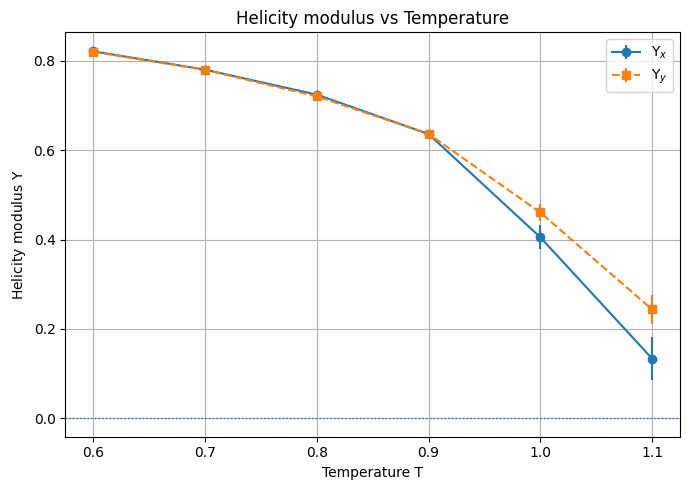

In [25]:
temps, Ux, Uy, Ux_err, Uy_err = compute_helicity_vs_temp(C, Tvals, do_bootstrap=True, nboot=200)
plot_helicity_vs_temp(temps, Ux, Uy, Ux_err=Ux_err, Uy_err=Uy_err)

In [31]:
# L = 64
# J = 1.0
# temps = np.arange(0.6, 1.4, 0.1)

# # Faster-but-still-reliable hyperparameters for L=64
# C_64, Tvals_64 = data_generation_internal(
#     L, J, temps,
#     ntherm=15000,   # thermalization sweeps (reduced from 20000/100000)
#     nsamples=15,    # saved samples per bin
#     nskip=500,      # sweeps between saved samples (larger => more independent)
#     nbin=2,         # independent restarts (reduced from 5)
#     delta=0.6       # proposal window (tune via probe_acceptance if needed)
# )

# print("Generated configs:", C_64.shape)   # (len(temps)*nbin*nsamples, L, L)

L = 64
J = 1.0
temps = np.arange(0.6, 1.4, 0.1)

# Balanced settings: more independent samples near critical region,
# but total work still reasonable.
C_64, Tvals_64 = data_generation_internal(
    L, J, temps,
    ntherm=25000,   # better thermalization for L=64
    nsamples=25,    # saved per bin (so per-T saved = nsamples * nbin)
    nskip=500,      # bigger skip -> more independent samples (critical!)
    nbin=2,         # two independent restarts
    delta=0.6       # default proposal window (tune with acceptance probe if needed)
)

print("Generated configs:", C_64.shape)



Generated configs: (400, 64, 64)


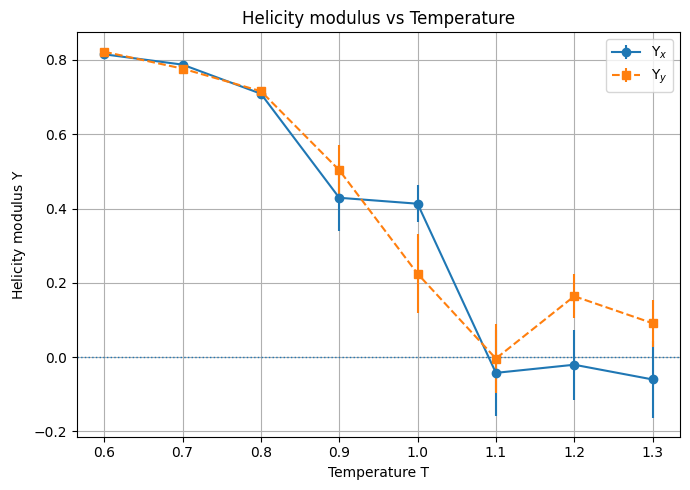

In [32]:
temps, Ux, Uy, Ux_err, Uy_err = compute_helicity_vs_temp(C_64, Tvals_64, do_bootstrap=True, nboot=200)
plot_helicity_vs_temp(temps, Ux, Uy, Ux_err=Ux_err, Uy_err=Uy_err)